# Squeezed cavity-QED reservoir: model, simulator and effective device parameters

## Statement of the problem
A physical reservoir computer maps an input time series into the transient response of a dynamical system and trains only a linear readout. Its quality depends on device parameters (input strength, coupling, detunings, relaxation of the nonlinear element) that are fixed at fabrication. **Can optical squeezing turn these fabrication parameters into post-fabrication controls?**

The device is a single cavity mode $a$ coupled to a two-level emitter $\sigma$, parametrically driven and coupled to a squeezed bath. In the frame rotating at half the pump frequency ($\phi_s=0$):
$$H_0=\omega_a a^\dagger a+\omega_q\sigma^\dagger\sigma-\tfrac{\lambda}{2}(a^2+a^{\dagger2})+g(a^\dagger\sigma+a\sigma^\dagger),\qquad H_{\rm in}=i\epsilon f(t)(a-a^\dagger),$$
$$\dot\rho=-i[H_0+H_{\rm in},\rho]+\mathcal D[L_a]\rho+\gamma\mathcal D[\sigma]\rho,\qquad L_a=\sqrt\kappa(\cosh r_e\,a+e^{i\theta}\sinh r_e\,a^\dagger).$$
Controls: $\vartheta=(r, r_e, \Delta\theta)$ with $\tanh 2r=\lambda/\omega_a$, $\Delta\theta=\theta-\phi_s$. Fabricated and fixed: $g,\kappa,\gamma,\epsilon,\omega_a,\omega_q$.

## Simulation method
* **Bogoliubov frame.** $a=\alpha\cosh r+\alpha^\dagger\sinh r$ diagonalizes the quadratic cavity part exactly: $\Omega_a=\omega_a/\cosh 2r$; the drive becomes $i\epsilon e^{-r}f(\alpha-\alpha^\dagger)$; the coupling $g\cosh r(\alpha^\dagger\sigma+{\rm h.c.})+g\sinh r(\alpha\sigma+{\rm h.c.})$. Truncation ($N_c=8$) is applied to the quasi-mode $\alpha$.
* **Real Hermitian basis.** Superoperators act on the real vector space of Hermitian matrices (dimension $D^2=324$), halving memory and quartering flops versus the complex vectorization.
* **Chebyshev-interpolated propagator.** The Liouvillian is linear in the input, $\mathcal L(f)=\mathcal L_0+f\mathcal L_1$; $e^{\mathcal L(f)\tau}$ is evaluated exactly (`scipy.linalg.expm`) at 7 Chebyshev nodes $f_k\in[-1,1]$ and reconstructed at each input by barycentric interpolation (error $<10^{-10}$).
* **Readout.** Six homodyne-accessible observables $Q,P,Q^2,P^2,\sigma_x,\sigma_y$ at $N_v=4$ virtual times per symbol, standardized, ridge with $\delta=N_{\rm tr}\sigma_{\rm rel}^2$, $\sigma_{\rm rel}=1\%$ (noise-matched).

The whole simulator is `sqz.py`; the device and task constants are in `common.py`.

In [1]:
import os, sys, subprocess, numpy as np
CODE = os.path.abspath(os.path.join(os.getcwd(), '..', 'code')); sys.path.insert(0, CODE); os.chdir(CODE); os.environ['OMP_NUM_THREADS'] = '1'
import matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from common import *
import make_figs
RUN = False   # set True to recompute the data for this notebook (see the "Compute" section for the cost)
def show(pdf, dpi=110):
    """Render a figure PDF from paper/figs inline."""
    base = '/tmp/' + os.path.basename(pdf)[:-4]; subprocess.run(['pdftoppm', '-r', str(dpi), '-png', '-singlefile', pdf, base], check=True); display(Image(filename=base + '.png'))
def ld(name):
    p = os.path.join(DATA, name); return np.load(p, allow_pickle=True) if os.path.exists(p) else None


In [2]:
from sqz import *
print(DEV)
task = MG
t0 = time.time(); L, nr, nmax = evaluate(DEV, (0, 0, 0), task); print('unsqueezed device on Mackey-Glass: L = %.4e, held-out NRMSE = %.3f, max photons = %.3f, time %.2f s' % (L, nr, nmax, time.time() - t0))

Device(omega=1.0, omega_q=1.0, g=0.5, kappa=0.2, gamma=0.1, eps=0.2, T_in=2.0, Nv=4, Nc=8, K=7, sigma_rel=0.01, s=1.0, phi_d=0.0)


unsqueezed device on Mackey-Glass: L = 7.0840e-03, held-out NRMSE = 0.521, max photons = 0.071, time 0.53 s


## Accuracy checks of the propagation
Chebyshev order and Fock cutoff (a corner of the control box is the most demanding point, because for $\Delta\theta=0$ the two squeezings add).

In [3]:
import sqz
res = Reservoir(replace(DEV, K=9), (0.5, 0.5, 0.0)); rng = np.random.default_rng(1); rho = res.rho0.copy()
for u in rng.uniform(-1, 1, 30): rho = res.exact_step(rho, u)
for K in (5, 7, 9):
    rk = Reservoir(replace(DEV, K=K), (0.5, 0.5, 0.0)); errs = []
    for u in rng.uniform(-1, 1, 5):
        C = sqz._cheb_coeffs(np.array([u]), rk.x, rk.w); P = (C[0] @ rk.Pflat).reshape(rk.D**2, rk.D**2); errs.append(np.abs(P @ rho - rk.exact_step(rho, u)).max())
    print('K = %d: max interpolation error %.1e' % (K, max(errs)))
for th in ((0, 0, 0), (0.02, 0.2, -0.52), (0.5, 0.5, 0.0)):
    print('theta', th, ['Nc=%d: L=%.5e n=%.3f' % (Nc, *[evaluate(replace(DEV, Nc=Nc), th, MG)[i] for i in (0, 2)]) for Nc in (8, 12)])

K = 5: max interpolation error 2.2e-09


K = 7: max interpolation error 3.1e-12


K = 9: max interpolation error 3.0e-15


theta (0, 0, 0) ['Nc=8: L=7.08401e-03 n=0.071', 'Nc=12: L=7.08401e-03 n=0.071']


theta (0.02, 0.2, -0.52) ['Nc=8: L=4.64447e-03 n=0.100', 'Nc=12: L=4.64447e-03 n=0.100']


theta (0.5, 0.5, 0.0) ['Nc=8: L=6.03871e-03 n=2.694', 'Nc=12: L=6.23779e-03 n=2.915']


## What each control does to the effective device
* $r$: input strength $\epsilon e^{\mp r}$ (sign set by the parametric phase $\phi_s$), couplings $g\cosh r$, $g\sinh r$, cavity frequency $\omega_a/\cosh 2r$.
* $r_e$, $\Delta\theta$: **mean-field lemma** $\frac{d}{dt}\langle a\rangle|_{\rm bath}=-\frac{\kappa}{2}\langle a\rangle$ for any $r_e,\theta$ (because $\cosh^2 r_e-\sinh^2 r_e=1$) — the external squeezing does not touch the cavity decay or the linear response; it acts only through the emitter, whose relaxation rate it sets, while the phase orients the intracavity noise.

`effective_parameters` computes $\epsilon_{\rm eff},\Omega_a,g\cosh r,g\sinh r$, the integrated emitter relaxation rates $\gamma^{\rm eff}_{x,y,z}$ and stationary variances; `run_review.liouvillian_gap` the spectral gap of $\mathcal L_0$ (equal to $(\kappa+\gamma)/4$ at zero squeezing).

In [4]:
from sqz import effective_parameters
from run_review import liouvillian_gap
for th in ((0, 0, 0), (0, 0.2, -0.79), (0, 0.5, -0.79), (0.3, 0, 0)):
    e = effective_parameters(DEV, th); print(th, {k: round(float(v), 3) for k, v in e.items()}, 'gap %.3f' % liouvillian_gap(DEV, th))

(0, 0, 0) {'eps_eff': 0.2, 'Omega': 1.0, 'g_co': 0.5, 'g_cr': 0.0, 'VarQ': 1.0, 'VarP': 1.0, 'n_ss': 0.0, 'ne_ss': 0.0, 'gamma_x': 0.187, 'gamma_y': 0.187, 'gamma_z': 0.279} gap 0.075


(0, 0.2, -0.79) {'eps_eff': 0.2, 'Omega': 1.0, 'g_co': 0.5, 'g_cr': 0.0, 'VarQ': 1.084, 'VarP': 1.027, 'n_ss': 0.028, 'ne_ss': 0.025, 'gamma_x': 0.211, 'gamma_y': 0.21, 'gamma_z': 0.293} gap 0.085


(0, 0.5, -0.79) {'eps_eff': 0.2, 'Omega': 1.0, 'g_co': 0.5, 'g_cr': 0.0, 'VarQ': 1.488, 'VarP': 1.33, 'n_ss': 0.204, 'ne_ss': 0.134, 'gamma_x': 0.333, 'gamma_y': 0.327, 'gamma_z': 0.372} gap 0.138


(0.3, 0, 0) {'eps_eff': 0.148, 'Omega': 0.844, 'g_co': 0.523, 'g_cr': 0.152, 'VarQ': 2.506, 'VarP': 0.619, 'n_ss': 0.281, 'ne_ss': 0.08, 'gamma_x': 0.258, 'gamma_y': 0.273, 'gamma_z': 0.307} gap 0.111


## Compute
`run_tasks.py` (effective-parameter lines, ~1 min) and `run_review.py gap` (~1 min) produce `data/tasks.npz` and `data/review.npz`; with `RUN=False` the saved data are used.

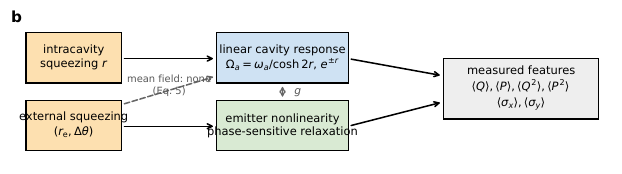

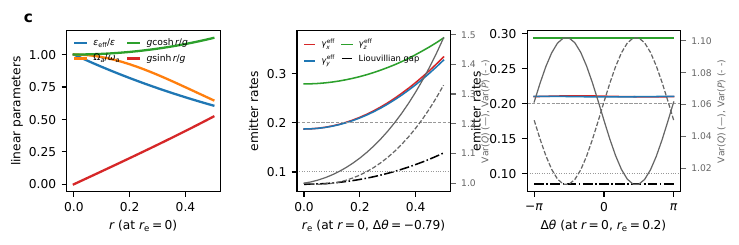

In [5]:
if RUN:
    subprocess.run(['python3', 'run_tasks.py']); subprocess.run(['python3', 'run_review.py', 'gap'])
make_figs.fig1(); make_figs.fig1_effective(); show('paper/figs/fig1_sketch.pdf'); show('paper/figs/fig1_effective.pdf')

**Figure 1c.** Linear device parameters against $r$ (left); emitter relaxation rates, Liouvillian gap and stationary quadrature variances against $r_e$ (middle) and against $\Delta\theta$ (right). The rates move with $r_e$, are phase independent, and the phase exchanges Var$(Q)$ and Var$(P)$.